##Level B | Medium

###Problem 2.1 Normalization and Standardization

In [ ]:
import pandas as pd

df = pd.read_csv("levelB.csv")
df.head()


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
df.info()

#Load and Analyze first

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
numeric_cols


Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
features = df[['residual sugar', 'alcohol']].dropna()
features.head()


,residual sugar,alcohol
0,20.7,8.8
1,1.6,9.5
2,6.9,10.1
3,8.5,9.9
4,8.5,9.9


In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
minmax_scaled = pd.DataFrame(
    minmax.fit_transform(features),
    columns=features.columns
)


Min max normalization is useful when features have bounded ranges or when distance-based algorithms are applied.

In [ ]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()
standard_scaled = pd.DataFrame(
    standard.fit_transform(features),
    columns=features.columns
)


standardization centers values around zero and scales them by standard deviation.
This method is preferred when data follow approximately normal distributions or when algorithms rely on variance

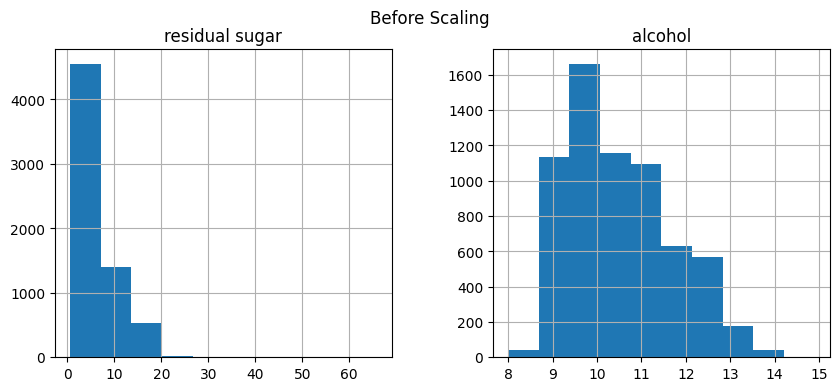

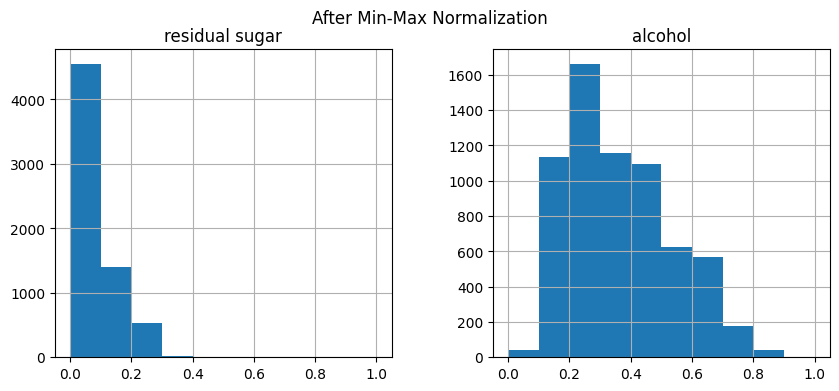

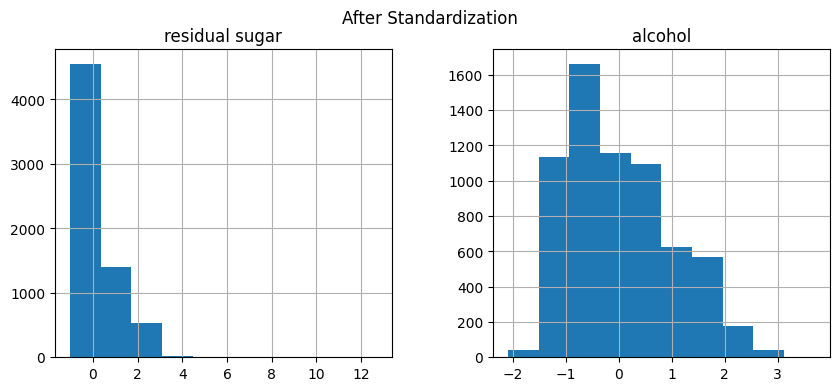

In [ ]:
import matplotlib.pyplot as plt

features.hist(figsize=(10,4))
plt.suptitle("Before Scaling")
plt.show()

minmax_scaled.hist(figsize=(10,4))
plt.suptitle("After Min-Max Normalization")
plt.show()

standard_scaled.hist(figsize=(10,4))
plt.suptitle("After Standardization")
plt.show()


The plots demonstrate that normalization changes scale while preserving distribution shape, whereas standardization shifts the distribution center and adjusts spread

###TAsk B2

In [ ]:
df['sweetness_acidity_ratio']=df['residual sugar']/ (df['fixed acidity'] + 1)


In [ ]:
df['sweet_bins_width'] = pd.cut(df['sweetness_acidity_ratio'], bins=4)


In [ ]:
df['sweet_bins_freq'] = pd.qcut(df['sweetness_acidity_ratio'], q=4)


In [ ]:
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True)
df_encoded.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,sweetness_acidity_ratio,sweet_bins_width,sweet_bins_freq,type_white
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,2.587500,"(1.916, 3.77]","(1.043, 7.477]",True
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,0.219178,"(0.0544, 1.916]","(0.214, 0.366]",True
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,0.758242,"(0.0544, 1.916]","(0.366, 1.043]",True
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,1.036585,"(0.0544, 1.916]","(0.366, 1.043]",True
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,1.036585,"(0.0544, 1.916]","(0.366, 1.043]",True


##D1 Measures of Similarity | 3. Analytical Tasks

In [ ]:
import numpy as np

numeric_df = df.select_dtypes(include=['int64','float64'])

v1 = numeric_df.iloc[0].values
v2 = numeric_df.iloc[1].values

v1, v2

(array([7.0000e+00, 2.7000e-01, 3.6000e-01, 2.0700e+01, 4.5000e-02,
        4.5000e+01, 1.7000e+02, 1.0010e+00, 3.0000e+00, 4.5000e-01,
        8.8000e+00, 6.0000e+00, 2.5875e+00]),
 array([6.30000000e+00, 3.00000000e-01, 3.40000000e-01, 1.60000000e+00,
        4.90000000e-02, 1.40000000e+01, 1.32000000e+02, 9.94000000e-01,
        3.30000000e+00, 4.90000000e-01, 9.50000000e+00, 6.00000000e+00,
        2.19178082e-01]))

In [ ]:
euclidean = np.sqrt(np.sum((v1 - v2)**2))
euclidean

np.float64(52.692427479727776)

In [ ]:
cosine = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
cosine

np.float64(0.9825515177699049)

In [ ]:
pearson = np.corrcoef(v1, v2)[0,1]
pearson

np.float64(0.9811730709422104)

In [ ]:
set1 = set(df['quality'].iloc[:10])
set2 = set(df['quality'].iloc[10:20])

jaccard = len(set1 & set2) / len(set1 | set2)
jaccard

0.25

Euclidean distance measures the geometric distance between two observations in multidimensional space. Cosine similarity measures the angle between vectors. Pearson correlation measures the strength of linear relationship between two vectors. Jaccard similarity measures the overlap between two sets relative to their union. The metrics differ:
Euclidean considers magnitude, cosine considers orientation, correlation considers linear dependence, and Jaccard measures shared elements

###D2 Dimensionlity Reduction

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df = numeric_df.dropna()
X = numeric_df.values

Before applying PCA, non-numeric attributes and missing values were removed.

In [ ]:
from sklearn.preprocessing import StandardScaler

X = numeric_df.dropna().values
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [ ]:
cov_matrix = np.cov(X_std.T)
cov_matrix

array([[ 1.00015475,  0.2210999 ,  0.32379432, -0.11345938,  0.29915021,
        -0.28352837, -0.33059418,  0.45978389, -0.25115943,  0.30131004,
        -0.09620476, -0.07618557, -0.21498431],
       [ 0.2210999 ,  1.00015475, -0.3775702 , -0.19670776,  0.37805353,
        -0.35345698, -0.41479306,  0.27214325,  0.26017402,  0.22569058,
        -0.03953412, -0.26671875, -0.21402539],
       [ 0.32379432, -0.3775702 ,  1.00015475,  0.14234565,  0.0394179 ,
         0.1322911 ,  0.19442809,  0.09708255, -0.32791095,  0.05907937,
        -0.01005737,  0.08493928,  0.10300291],
       [-0.11345938, -0.19670776,  0.14234565,  1.00015475, -0.12883381,
         0.40351103,  0.49576071,  0.55157971, -0.26652187, -0.18564472,
        -0.35918721, -0.03465914,  0.98875602],
       [ 0.29915021,  0.37805353,  0.0394179 , -0.12883381,  1.00015475,
        -0.19545783, -0.27964539,  0.36316377,  0.04465987,  0.39630103,
        -0.25770367, -0.20058421, -0.15218706],
       [-0.28352837, -0.353456

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [ ]:
idx = np.argsort(eigenvalues)[::-1]
top2_vectors = eigenvectors[:, idx[:2]]

In [ ]:
X_pca = X_std @ top2_vectors

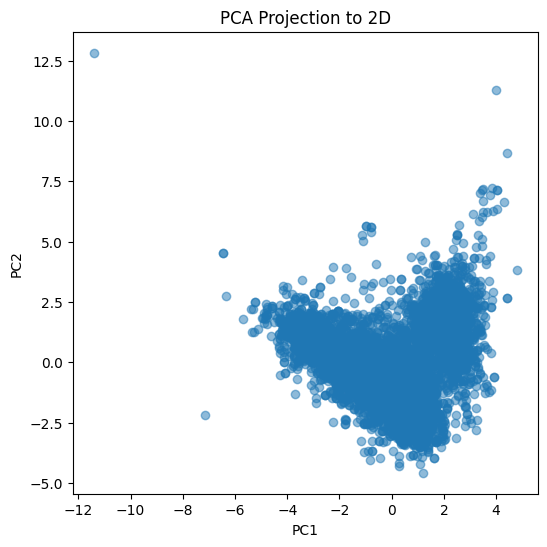

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title("PCA Projection to 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

The data were first standardized so that each feature contributes equally to variance.
The covariance matrix was computed to measure relationships between variables

Eigenvalues represent the amount of variance explained by each principal component, while eigenvectors represent directions of maximum variance

##Level C | Hard

In [ ]:
dfC = pd.read_csv("LevelC.csv")
dfC.head()


,Unnamed: 0,id,name,rating,reviews,host_name,host_id,address,features,amenities,...,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
0,0,49849504,Perla bungalov,4.71,64,Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...",...,8078,Turkey,1,1,2,0,2,0,Flexible,12 00 pm
1,1,50891766,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873.0,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...",...,4665,Turkey,2,2,4,0,2,0,4 00 pm - 11 00 pm,10 00 am
2,2,50699164,cottages sataplia,4.85,68,Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...",...,5991,Georgia,1,3,4,0,1,0,After 1 00 pm,12 00 pm
3,3,49871422,Sapanca Breathable Bungalow,5.0,13,Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...",...,11339,Turkey,1,2,4,0,1,0,After 2 00 pm,12 00 pm
4,4,51245886,Bungalov Ev 2,New,0,Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...",...,6673,Turkey,1,1,2,0,1,0,After 2 00 pm,12 00 pm


A large dataset was selected to evaluate how different sampling strategies affect representativeness and statistical properties

In [ ]:
random_sample = dfC.sample(frac=0.10, random_state=42)

In [ ]:
strat_sample = dfC.groupby('rating', group_keys=False)\
                 .apply(lambda x: x.sample(frac=0.10, random_state=42))

/tmp/ipython-input-3295080428.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.10, random_state=42))


In [ ]:
clusters = dfC['address'].unique()

chosen_clusters = np.random.choice(clusters,
                                   size=int(len(clusters)*0.3),
                                   replace=False)

cluster_sample = dfC[dfC['address'].isin(chosen_clusters)]

In [ ]:
def stats(df):
    num = df.select_dtypes(include=['int64','float64'])
    return pd.DataFrame({
        'mean': num.mean(),
        'median': num.median(),
        'variance': num.var(),
        'IQR': num.quantile(0.75) - num.quantile(0.25)
    })

full_stats = stats(dfC)
random_stats = stats(random_sample)
strat_stats = stats(strat_sample)
cluster_stats = stats(cluster_sample)

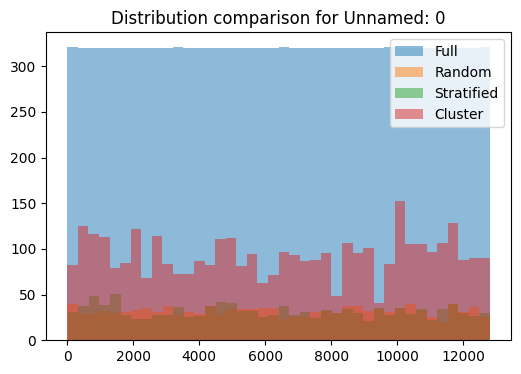

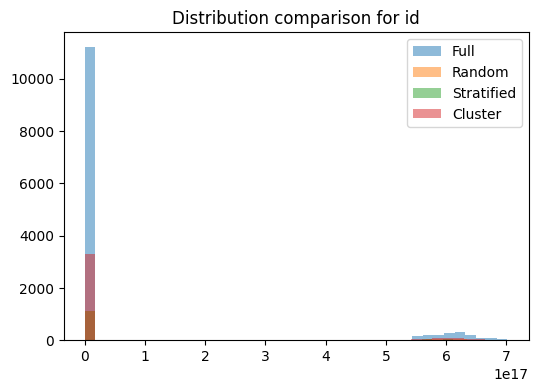

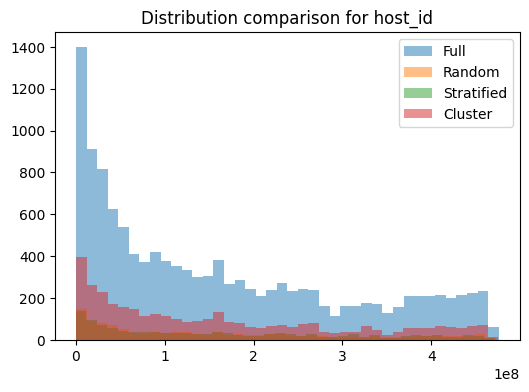

In [ ]:
cols = dfC.select_dtypes(include=['int64','float64']).columns[:3]

for c in cols:
    plt.figure(figsize=(6,4))
    plt.hist(dfC[c], bins=40, alpha=0.5, label='Full')
    plt.hist(random_sample[c], bins=40, alpha=0.5, label='Random')
    plt.hist(strat_sample[c], bins=40, alpha=0.5, label='Stratified')
    plt.hist(cluster_sample[c], bins=40, alpha=0.5, label='Cluster')
    plt.legend()
    plt.title(f"Distribution comparison for {c}")
    plt.show()

Simple random sampling produces an unbiased subset but may not preserve category proportions or rare patterns, which can influence variance and outlier detection. Cluster sampling reduces computational cost by selecting entire groups, but may distort distributions if clusters differ internally. This approach is efficient for geographically distributed or grouped data. Cluster sampling is most useful when data collection cost is the main constraint.